In [1]:
from __future__ import print_function
import os
import sys

# Temporary workaround for Windows OpenMP duplicate runtime initialization in notebooks.
# Must be set before importing torch/torchvision/numpy-linked libraries.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Set up absolute path to the root of the project for importing custom modules.
sys.path.append(os.path.abspath("../.."))

# Import necessary torch libraries
import torch
import torch.optim as optim
import torchvision.transforms as transforms

# Import Model
from models.RESNET.RESNET_d import ResNet, ResidualBlock

# Import utils
from utils.train_val_utils import train_and_evaluate
from utils.dataloader_utils import dataloader
from utils.display_image_utils import display_original_vs_augmented
from utils.show_best_model_utils import show_best_model
from utils.load_best_model_utils import load_best_model
from utils.retrieve_results_from_ckpt_utils import results_from_ckpt
from utils.plot_train_val_curve_utils import plot_training_curves

# Set random seed for reproducibility
torch.manual_seed(42)

In [2]:
use_cuda = True
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if (use_cuda and torch.cuda.is_available()) else "cpu")
print(f"Using device: {device}")

CUDA available: True
Using device: cuda


In [3]:
# Tensor conversion
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load datasets and dataloaders without augmentation for training dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform,
    transform_eval=transform,
    batch_size=32,
    num_workers=4
)

Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 3538
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 442
Classes: ['0_non-hybrid', '1_hybrid']
Class->idx: {'0_non-hybrid': 0, '1_hybrid': 1}
Total: 444


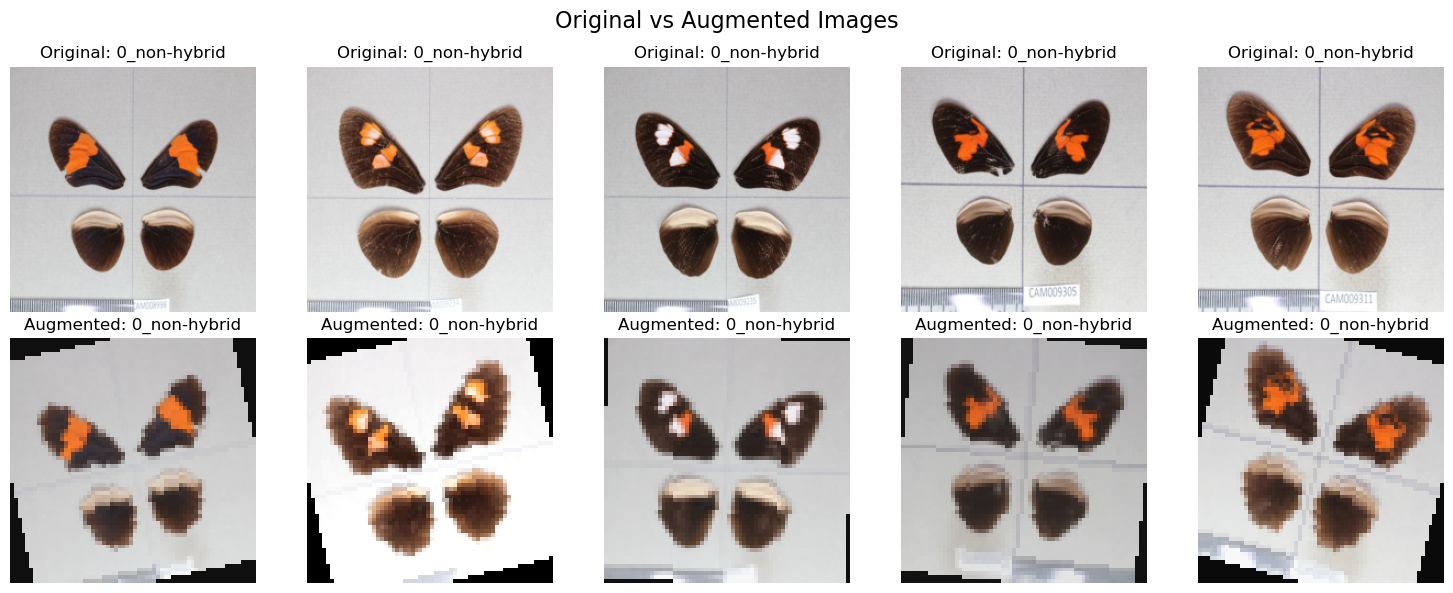

In [4]:
# Data augmentation transforms for training dataset
transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Data augmentation transforms for validation and test datasets (only resizing and tensor conversion)
transform_eval = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Load datasets and dataloaders with augmentation for training dataset
train_dataset_aug, val_dataset, test_dataset, train_loader_aug, val_loader, test_loader = dataloader(
    train_root="../../butterfly_anomaly_image_resized/final_dataset/train",
    val_root="../../butterfly_anomaly_image_resized/final_dataset/val",
    test_root="../../butterfly_anomaly_image_resized/final_dataset/test",
    transform_train=transform_train,
    transform_eval=transform_eval,
    batch_size=32,
    num_workers=4
)

assert train_dataset_aug.class_to_idx == val_dataset.class_to_idx == test_dataset.class_to_idx

display_original_vs_augmented(train_dataset, train_dataset_aug)

In [ ]:
learning_rate_values = [0.01, 0.005, 0.001, 0.0001]
weight_decay_values = [1e-3, 1e-4, 1e-5, 1e-6]
class_weights_values = [2.5, 3.5, 4.5, 5.5]
batch_size_values = [16, 32, 64, 128]
layer_configurations = [[2, 2, 2], [3, 2, 2], [3, 3, 3], [4, 3, 3]]

model_resnet_d_dict = {}
optimizer_d_dict = {}
results_d_dict = {}
best_d_dict = {}
best_f2_d_dict = {}

count = 1

best_learning_rate_dict = {}
best_weight_decay_dict = {}
best_class_weights_val_dict = {}
best_batch_size_dict = {}
best_layer_configuration_dict = {}

best_learning_rate = 0.01
best_weight_decay = 1e-3
best_class_weights_val = 2.5
best_batch_size = 16
best_layer_configuration = [2, 2, 2]

best_f2 = float("-inf")

# Hyperparameter tuning loop for learning rate
for learning_rate in learning_rate_values:
    model_resnet_d_dict[f"model_resnet_d{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_resnet_d_dict[f"model_resnet_d{count}"].parameters(), lr=learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model D{count} with learning rate {learning_rate}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_resnet_d_dict[f"model_resnet_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_resnet_d_dict[f"model_resnet_d{count}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_d{count}"] = best_layer_configuration
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_learning_rate = learning_rate
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for weight decay
for weight_decay in weight_decay_values[1:]:
    model_resnet_d_dict[f"model_resnet_d{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_resnet_d_dict[f"model_resnet_d{count}"].parameters(), lr=best_learning_rate, weight_decay=weight_decay)
    print(f"\nTraining RESNET Model D{count} with weight decay {weight_decay}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_resnet_d_dict[f"model_resnet_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_resnet_d_dict[f"model_resnet_d{count}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_d{count}"] = best_layer_configuration
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_weight_decay = weight_decay
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for class weights
for class_weights_val in class_weights_values[1:]:
    model_resnet_d_dict[f"model_resnet_d{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_resnet_d_dict[f"model_resnet_d{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model D{count} with class weights {class_weights_val}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_resnet_d_dict[f"model_resnet_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_resnet_d_dict[f"model_resnet_d{count}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_d{count}"] = best_layer_configuration
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_class_weights_val = class_weights_val
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for batch size
for batch_size in batch_size_values[1:]:
    model_resnet_d_dict[f"model_resnet_d{count}"] = ResNet(ResidualBlock, best_layer_configuration, num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_resnet_d_dict[f"model_resnet_d{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model D{count} with batch size {batch_size}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_resnet_d_dict[f"model_resnet_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_resnet_d_dict[f"model_resnet_d{count}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = batch_size
    best_layer_configuration_dict[f"best_layer_configuration_d{count}"] = best_layer_configuration
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_batch_size = batch_size
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]

# Hyperparameter tuning loop for layer configuration
for layer_configuration in layer_configurations[1:]:
    model_resnet_d_dict[f"model_resnet_d{count}"] = ResNet(ResidualBlock, layer_configuration, num_classes=2).to(device)
    optimizer_d_dict[f"optimizer_d{count}"] = optim.Adam(model_resnet_d_dict[f"model_resnet_d{count}"].parameters(), lr=best_learning_rate, weight_decay=best_weight_decay)
    print(f"\nTraining RESNET Model D{count} with layer configuration {layer_configuration}")
    results_d_dict[f"results_d{count}"] = train_and_evaluate(model_resnet_d_dict[f"model_resnet_d{count}"], train_dataset_aug, val_dataset, optimizer_d_dict[f"optimizer_d{count}"], num_epochs=30, batch_size=best_batch_size, class_weights_val=best_class_weights_val, ckpt_file=f"saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl", device=device, num_workers=0)
    best_d_dict[f"best_d{count}"], best_f2_d_dict[f"best_f2_d{count}"] = show_best_model(model_resnet_d_dict[f"model_resnet_d{count}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{count}_log.pkl")
    best_learning_rate_dict[f"best_learning_rate_d{count}"] = best_learning_rate
    best_weight_decay_dict[f"best_weight_decay_d{count}"] = best_weight_decay
    best_class_weights_val_dict[f"best_class_weights_val_d{count}"] = best_class_weights_val
    best_batch_size_dict[f"best_batch_size_d{count}"] = best_batch_size
    best_layer_configuration_dict[f"best_layer_configuration_d{count}"] = layer_configuration
    count += 1
    if best_f2_d_dict[f"best_f2_d{count-1}"] > best_f2:
        best_layer_configuration = layer_configuration
        best_f2 = best_f2_d_dict[f"best_f2_d{count-1}"]


Training RESNET Model D1 with learning rate 0.01
  [Epoch 1] Improvement! New best score: 0.000000
Epoch [5/30], Train Loss: 0.6262, Val Loss: 0.5310, Train F1-Macro: 0.4550, Val F1-Macro: 0.4550, Train F1-Per-Class: [0.9100431 0.       ], Val F1-Per-Class: [0.9099877 0.       ], Train F2-Macro: 0.4810, Val F2-Macro: 0.4810, Train F2-Per-Class: [0.9619643 0.       ], Val F2-Per-Class: [0.9619395 0.       ], No improvement: 4/6
Epoch [5/30], Epoch [5/30], Train Loss: 0.6262, Val Loss: 0.5310, Train F1-Macro: 0.4550, Val F1-Macro: 0.4550, Train F1-Per-Class: [0.9100431 0.       ], Val F1-Per-Class: [0.9099877 0.       ] Train F2-Macro: 0.4810, Val F2-Macro: 0.4810, Train F2-Per-Class: [0.9619643 0.       ], Val F2-Per-Class: [0.9619395 0.       ]

Early stopping at epoch 7. No improvement for 6 epochs.
Restored model weights from best epoch (score: 0.000000)
Selected epoch: 1
Best val F2(class 1): 0.0

Training RESNET Model D2 with learning rate 0.005
  [Epoch 1] Improvement! New best s

In [5]:
# Restore best hyperparameters for model_d
best_learning_rate_dict = {'best_learning_rate_d1': 0.01, 'best_learning_rate_d2': 0.005, 'best_learning_rate_d3': 0.001, 'best_learning_rate_d4': 0.0001, 'best_learning_rate_d5': 0.0001, 'best_learning_rate_d6': 0.0001, 'best_learning_rate_d7': 0.0001, 'best_learning_rate_d8': 0.0001, 'best_learning_rate_d9': 0.0001, 'best_learning_rate_d10': 0.0001, 'best_learning_rate_d11': 0.0001, 'best_learning_rate_d12': 0.0001, 'best_learning_rate_d13': 0.0001, 'best_learning_rate_d14': 0.0001, 'best_learning_rate_d15': 0.0001, 'best_learning_rate_d16': 0.0001}
best_weight_decay_dict = {'best_weight_decay_d1': 0.001, 'best_weight_decay_d2': 0.001, 'best_weight_decay_d3': 0.001, 'best_weight_decay_d4': 0.001, 'best_weight_decay_d5': 0.0001, 'best_weight_decay_d6': 1e-05, 'best_weight_decay_d7': 1e-06, 'best_weight_decay_d8': 0.0001, 'best_weight_decay_d9': 0.0001, 'best_weight_decay_d10': 0.0001, 'best_weight_decay_d11': 0.0001, 'best_weight_decay_d12': 0.0001, 'best_weight_decay_d13': 0.0001, 'best_weight_decay_d14': 0.0001, 'best_weight_decay_d15': 0.0001, 'best_weight_decay_d16': 0.0001}
best_class_weights_val_dict = {'best_class_weights_val_d1': 2.5, 'best_class_weights_val_d2': 2.5, 'best_class_weights_val_d3': 2.5, 'best_class_weights_val_d4': 2.5, 'best_class_weights_val_d5': 2.5, 'best_class_weights_val_d6': 2.5, 'best_class_weights_val_d7': 2.5, 'best_class_weights_val_d8': 3.5, 'best_class_weights_val_d9': 4.5, 'best_class_weights_val_d10': 5.5, 'best_class_weights_val_d11': 4.5, 'best_class_weights_val_d12': 4.5, 'best_class_weights_val_d13': 4.5, 'best_class_weights_val_d14': 4.5, 'best_class_weights_val_d15': 4.5, 'best_class_weights_val_d16': 4.5}
best_batch_size_dict = {'best_batch_size_d1': 16, 'best_batch_size_d2': 16, 'best_batch_size_d3': 16, 'best_batch_size_d4': 16, 'best_batch_size_d5': 16, 'best_batch_size_d6': 16, 'best_batch_size_d7': 16, 'best_batch_size_d8': 16, 'best_batch_size_d9': 16, 'best_batch_size_d10': 16, 'best_batch_size_d11': 32, 'best_batch_size_d12': 64, 'best_batch_size_d13': 128, 'best_batch_size_d14': 16, 'best_batch_size_d15': 16, 'best_batch_size_d16': 16}
best_layer_configuration_dict = {'best_layer_configuration_d1': [2, 2, 2], 'best_layer_configuration_d2': [2, 2, 2], 'best_layer_configuration_d3': [2, 2, 2], 'best_layer_configuration_d4': [2, 2, 2], 'best_layer_configuration_d5': [2, 2, 2], 'best_layer_configuration_d6': [2, 2, 2], 'best_layer_configuration_d7': [2, 2, 2], 'best_layer_configuration_d8': [2, 2, 2], 'best_layer_configuration_d9': [2, 2, 2], 'best_layer_configuration_d10': [2, 2, 2], 'best_layer_configuration_d11': [2, 2, 2], 'best_layer_configuration_d12': [2, 2, 2], 'best_layer_configuration_d13': [2, 2, 2], 'best_layer_configuration_d14': [3, 2, 2], 'best_layer_configuration_d15': [3, 3, 3], 'best_layer_configuration_d16': [4, 3, 3]}

# Initialize model_resnet_d_dict with ResNet instances for each hyperparameter combination
model_resnet_d_dict = {
    'model_resnet_d1': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d2': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d3': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d4': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d5': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d6': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d7': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d8': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d9': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d10': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d11': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d12': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d13': ResNet(ResidualBlock, [2, 2, 2], num_classes=2).to(device),
    'model_resnet_d14': ResNet(ResidualBlock, [3, 2, 2], num_classes=2).to(device),
    'model_resnet_d15': ResNet(ResidualBlock, [3, 3, 3], num_classes=2).to(device),
    'model_resnet_d16': ResNet(ResidualBlock, [4, 3, 3], num_classes=2).to(device)
}

best_d_dict = {}
best_f2_d_dict = {}

In [7]:
for i in range(1, 8):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_d{i}']}"
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_resnet_d_dict[f"model_resnet_d{i}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{i}_log.pkl")

Model D1 | lr=0.01 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 1
Best val F2(class 0): 0.9619395136833191
Best val F2(class 1): 0.0
Model D2 | lr=0.005 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 2
Best val F2(class 0): 0.8256632089614868
Best val F2(class 1): 0.09641873091459274
Model D3 | lr=0.001 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 9
Best val F2(class 0): 0.8718662858009338
Best val F2(class 1): 0.8072289228439331
Model D4 | lr=0.0001 | wd=0.001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 23
Best val F2(class 0): 0.9679173231124878
Best val F2(class 1): 0.8894878625869751
Model D5 | lr=0.0001 | wd=0.0001 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 30
Best val F2(class 0): 0.9842733144760132
Best val F2(class 1): 0.9289617538452148
Model D6 | lr=0.0001 | wd=1e-05 | class_w=2.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 24
Best val F2(class 0): 0.9799131155014038
Best val F2(class

In [9]:
for i in range(8, 15):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_d{i}']}"
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_resnet_d_dict[f"model_resnet_d{i}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{i}_log.pkl")

Model D8 | lr=0.0001 | wd=0.0001 | class_w=3.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 19
Best val F2(class 0): 0.9756097793579102
Best val F2(class 1): 0.8767123222351074
Model D9 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 22
Best val F2(class 0): 0.9678298830986023
Best val F2(class 1): 0.9308510422706604
Model D10 | lr=0.0001 | wd=0.0001 | class_w=5.5 | bs=16 | layers=[2, 2, 2]
Selected epoch: 28
Best val F2(class 0): 0.9243929386138916
Best val F2(class 1): 0.9045225977897644
Model D11 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=32 | layers=[2, 2, 2]
Selected epoch: 8
Best val F2(class 0): 0.8751393556594849
Best val F2(class 1): 0.8293269276618958
Model D12 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=64 | layers=[2, 2, 2]
Selected epoch: 25
Best val F2(class 0): 0.911098837852478
Best val F2(class 1): 0.8521303534507751
Model D13 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=128 | layers=[2, 2, 2]
Selected epoch: 7
Best val F2(class 0): 0.817307

In [11]:
for i in range(15, 17):
    print(
        f"Model D{i} | "
        f"lr={best_learning_rate_dict[f'best_learning_rate_d{i}']} | "
        f"wd={best_weight_decay_dict[f'best_weight_decay_d{i}']} | "
        f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{i}']} | "
        f"bs={best_batch_size_dict[f'best_batch_size_d{i}']} | "
        f"layers={best_layer_configuration_dict[f'best_layer_configuration_d{i}']}"
    )
    best_d_dict[f"best_d{i}"], best_f2_d_dict[f"best_f2_d{i}"] = show_best_model(model=model_resnet_d_dict[f"model_resnet_d{i}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{i}_log.pkl")

Model D15 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=16 | layers=[3, 3, 3]
Selected epoch: 16
Best val F2(class 0): 0.9656301140785217
Best val F2(class 1): 0.9283819794654846
Model D16 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=16 | layers=[4, 3, 3]
Selected epoch: 19
Best val F2(class 0): 0.9002770185470581
Best val F2(class 1): 0.8518518805503845


In [12]:
# Pick the model index with highest validation F2 (class 1) among all collected runs
best_f2_key = max(best_f2_d_dict, key=lambda k: float(best_f2_d_dict[k]))
best_i = int(best_f2_key.split("d")[-1])

model = model_resnet_d_dict[f"model_resnet_d{best_i}"]
best = best_d_dict[f"best_d{best_i}"]

print(
    f"Selected Best Model D{best_i} | "
    f"val_f2_class1={float(best_f2_d_dict[best_f2_key]):.6f} | "
    f"lr={best_learning_rate_dict[f'best_learning_rate_d{best_i}']} | "
    f"wd={best_weight_decay_dict[f'best_weight_decay_d{best_i}']} | "
    f"class_w={best_class_weights_val_dict[f'best_class_weights_val_d{best_i}']} | "
    f"bs={best_batch_size_dict[f'best_batch_size_d{best_i}']} | "
    f"layers={best_layer_configuration_dict[f'best_layer_configuration_d{best_i}']}"
)

# Load the best model and evaluate on the test dataset
load_best_model(best_model=model, best=best, test_dataset=test_dataset, device=device)

Selected Best Model D9 | val_f2_class1=0.930851 | lr=0.0001 | wd=0.0001 | class_w=4.5 | bs=16 | layers=[2, 2, 2]
Test loss: 0.17211203875818423
Test F2 macro: 0.9511687755584717
Test F2 per class: [0.9739555 0.928382 ]
Test F2 for class 1 (1_hybrid): 0.9283819794654846


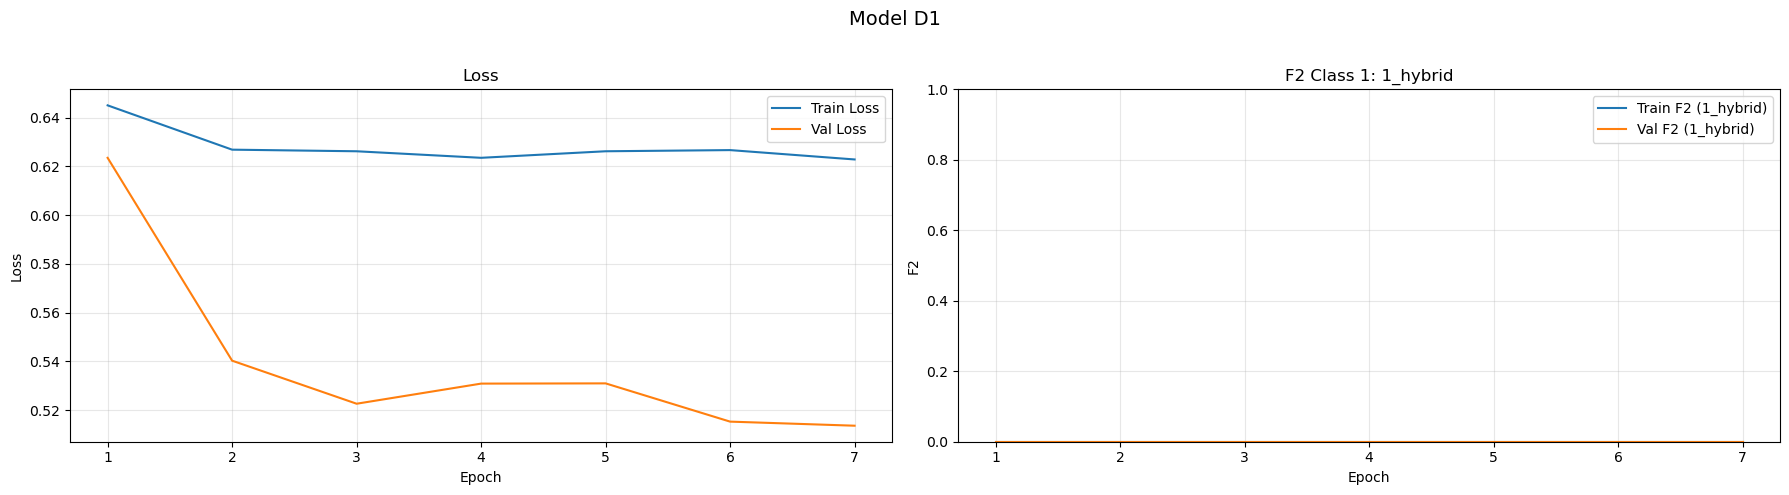

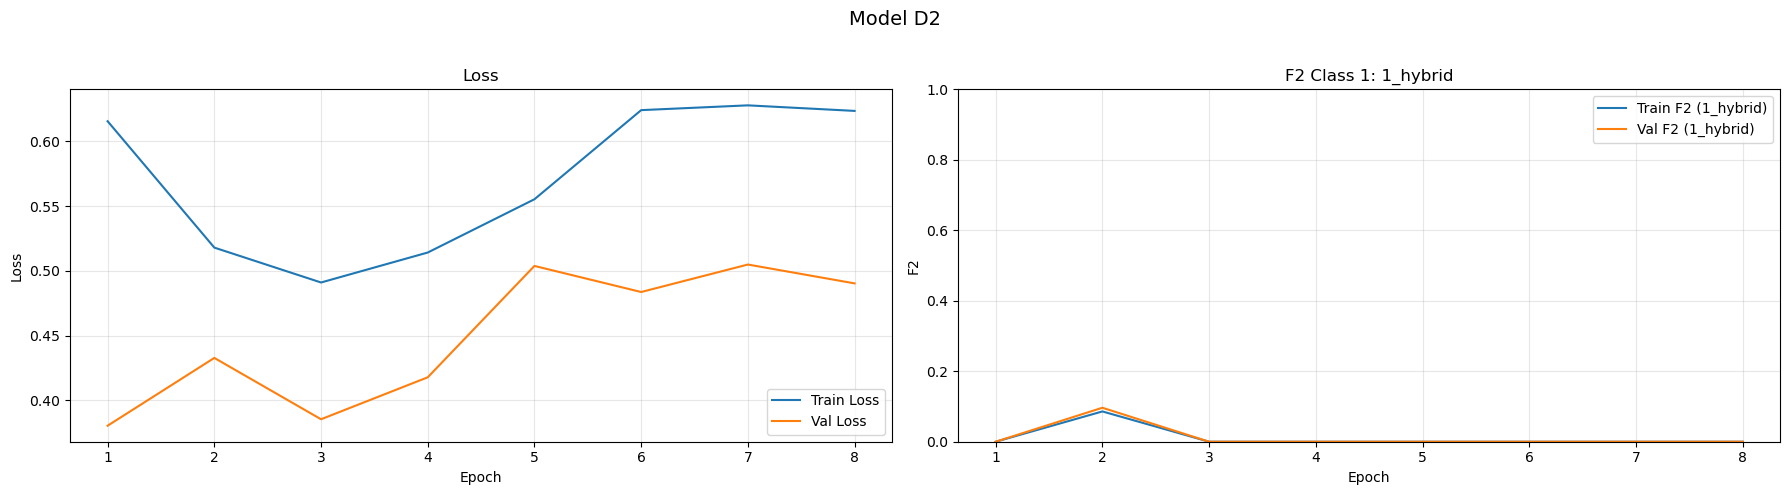

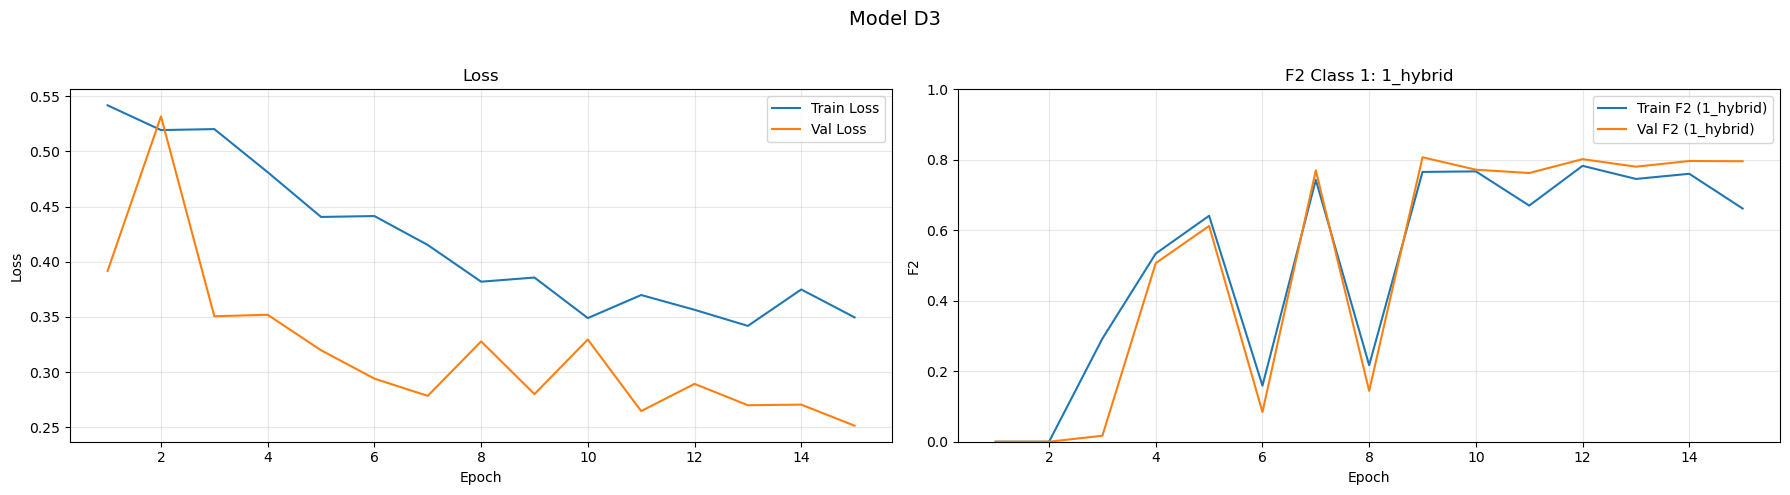

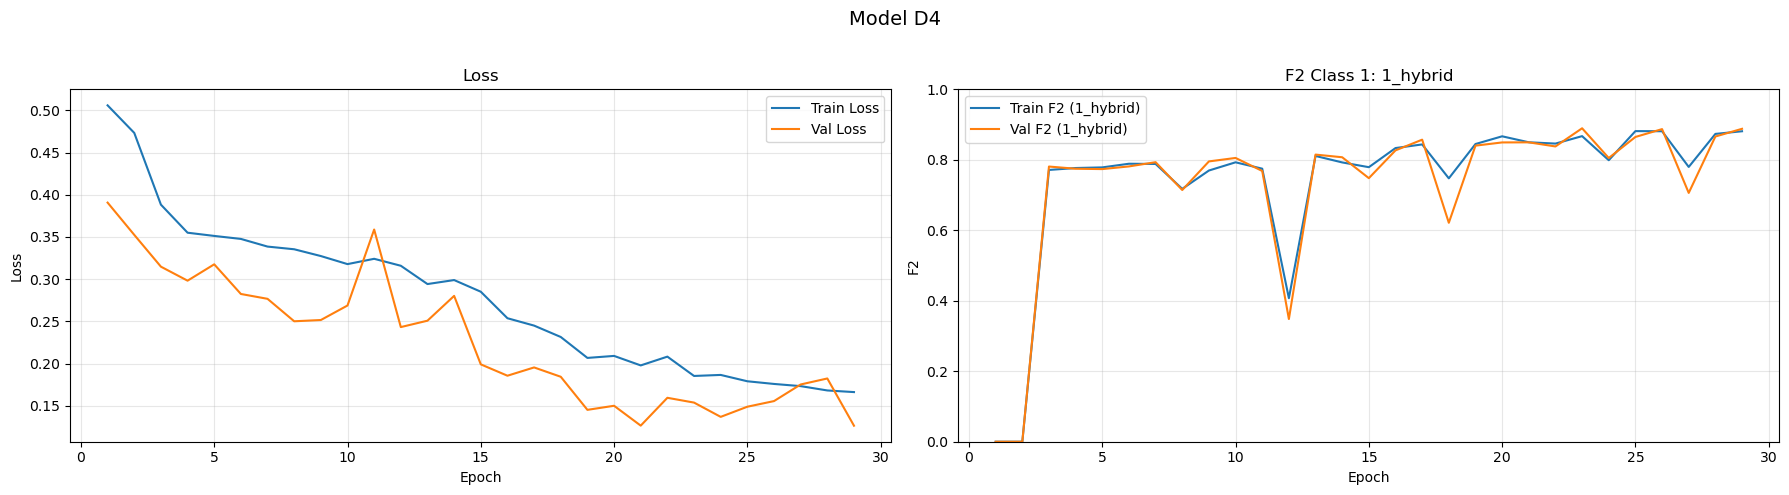

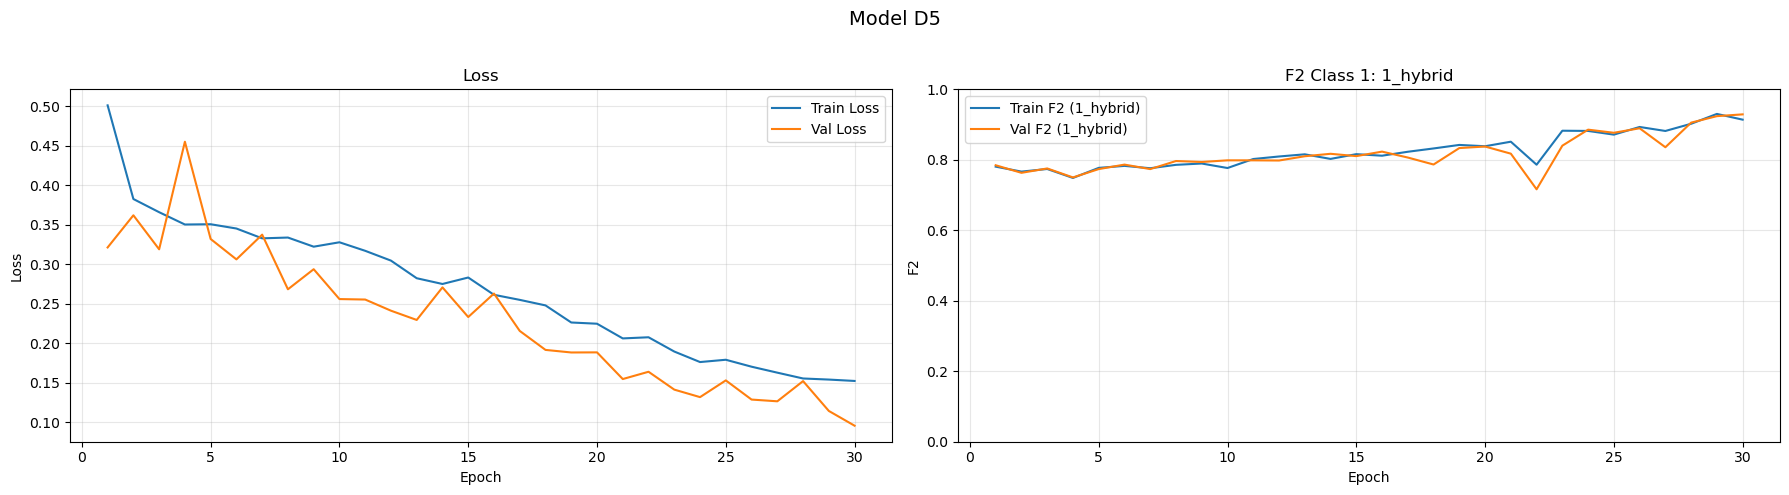

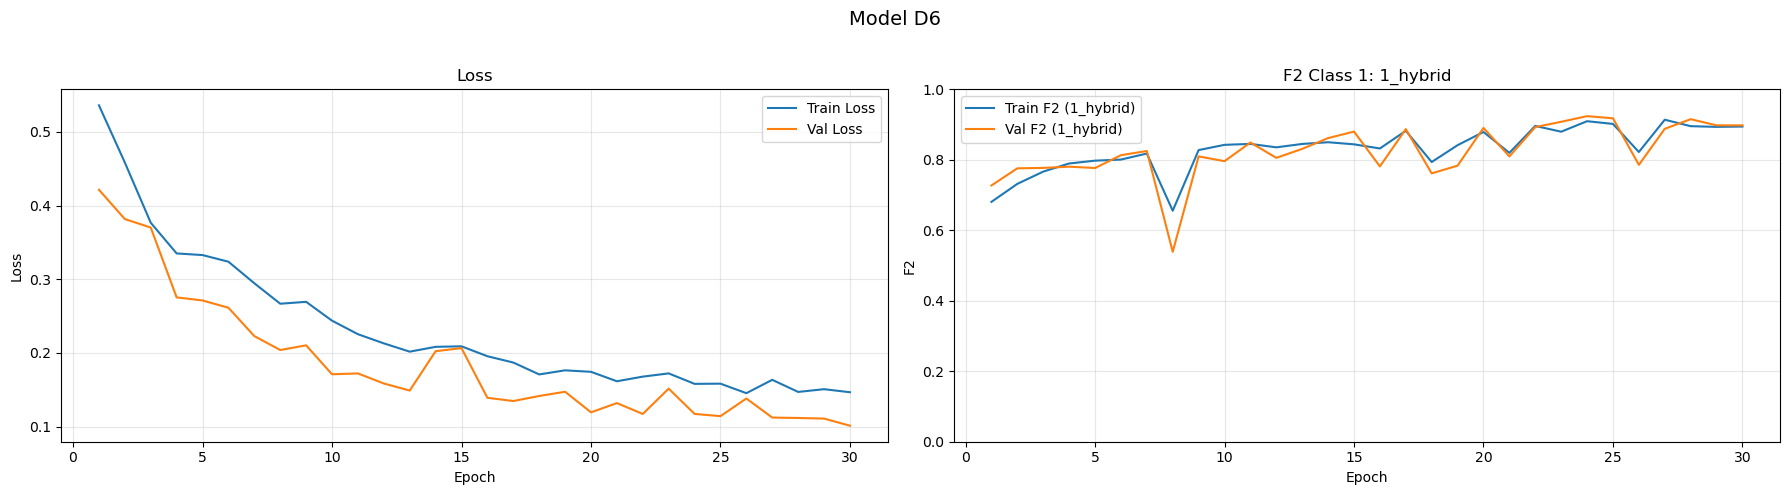

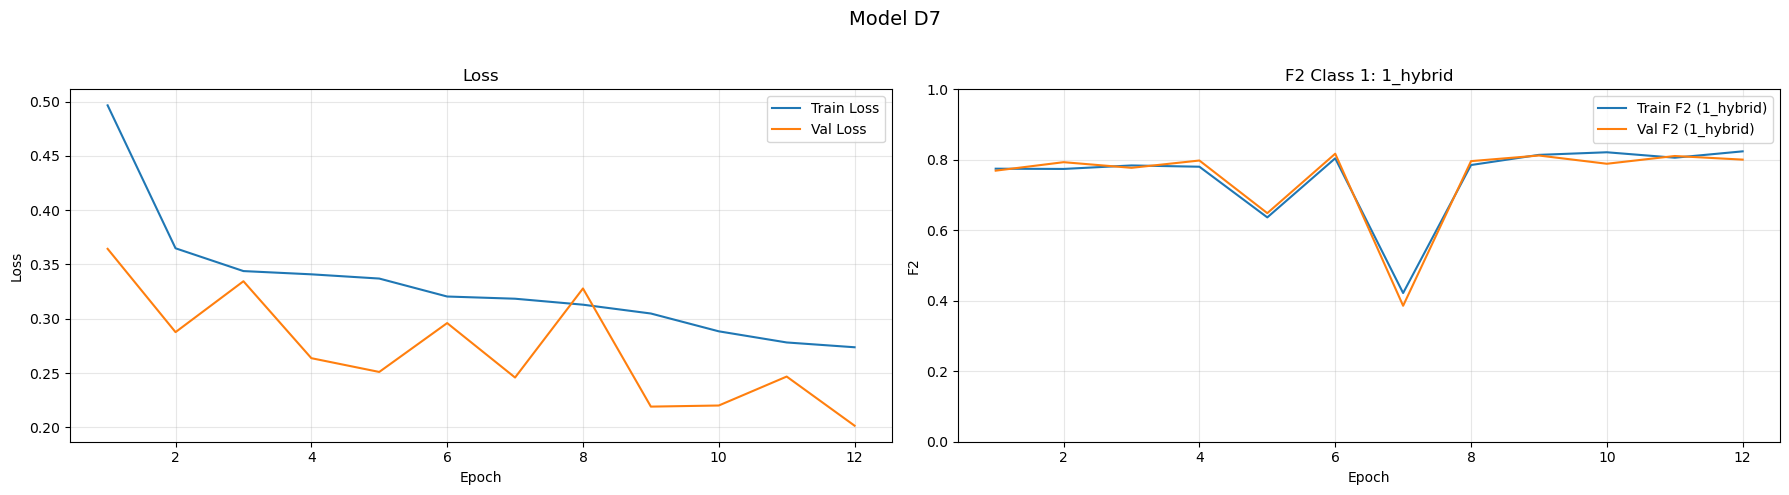

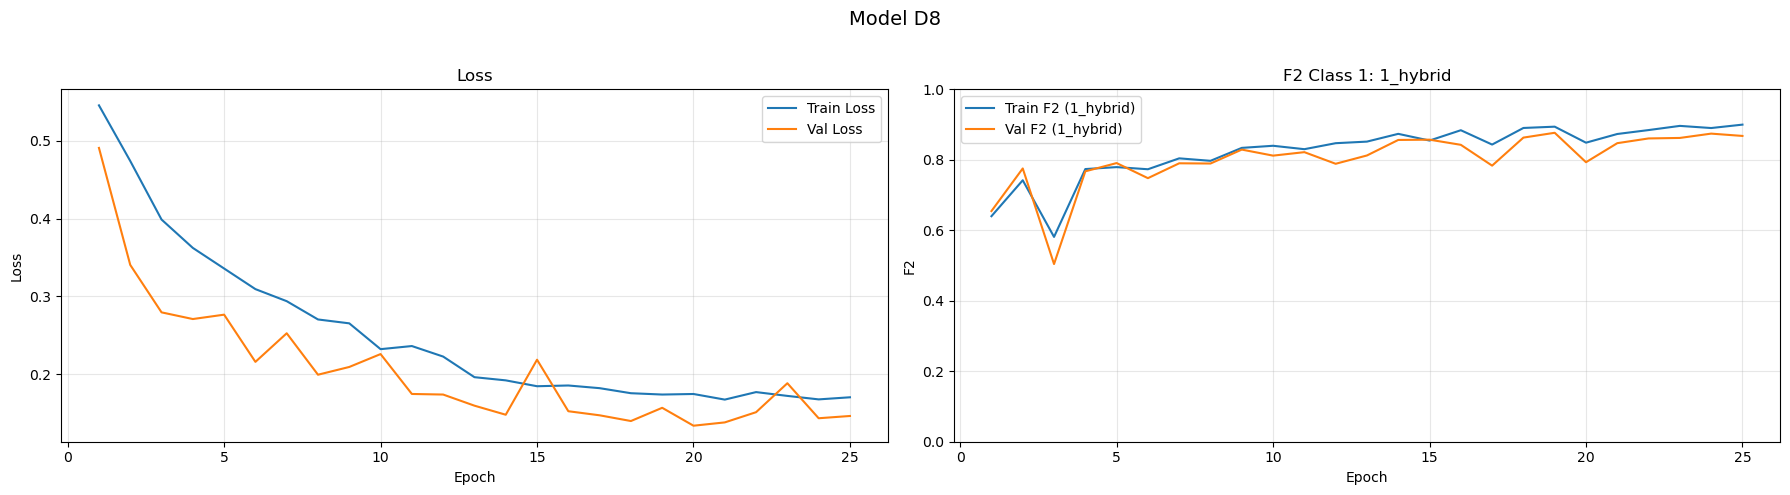

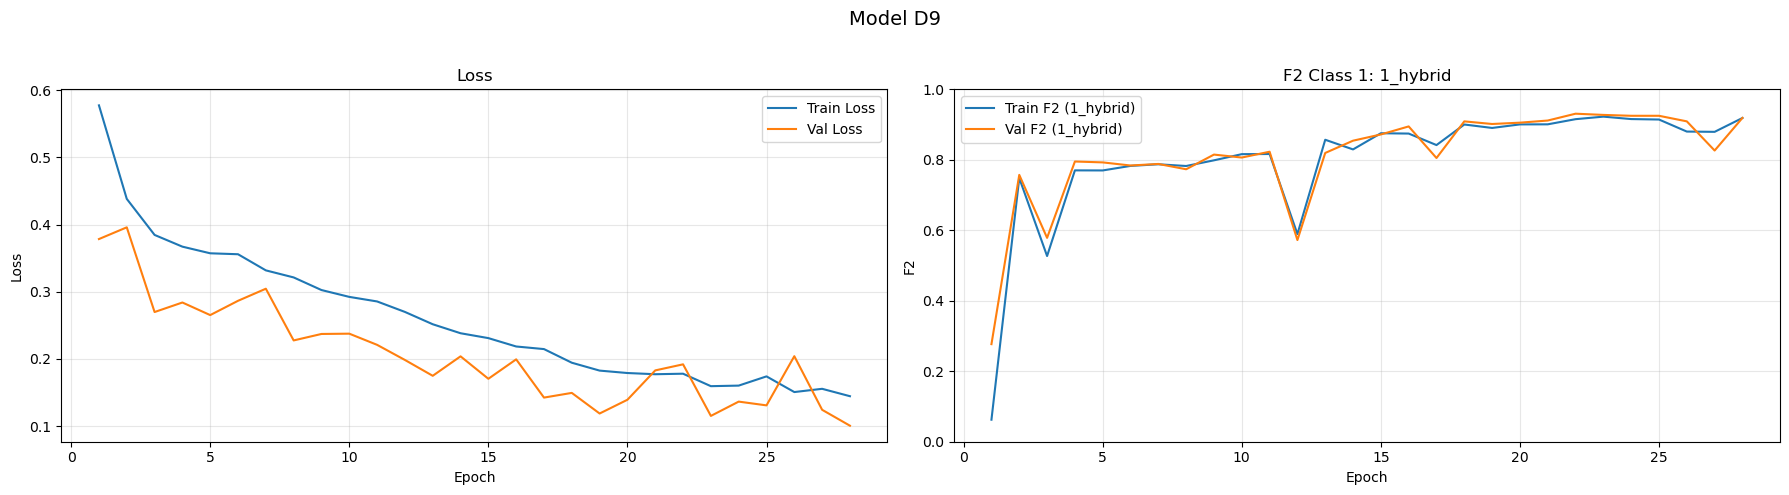

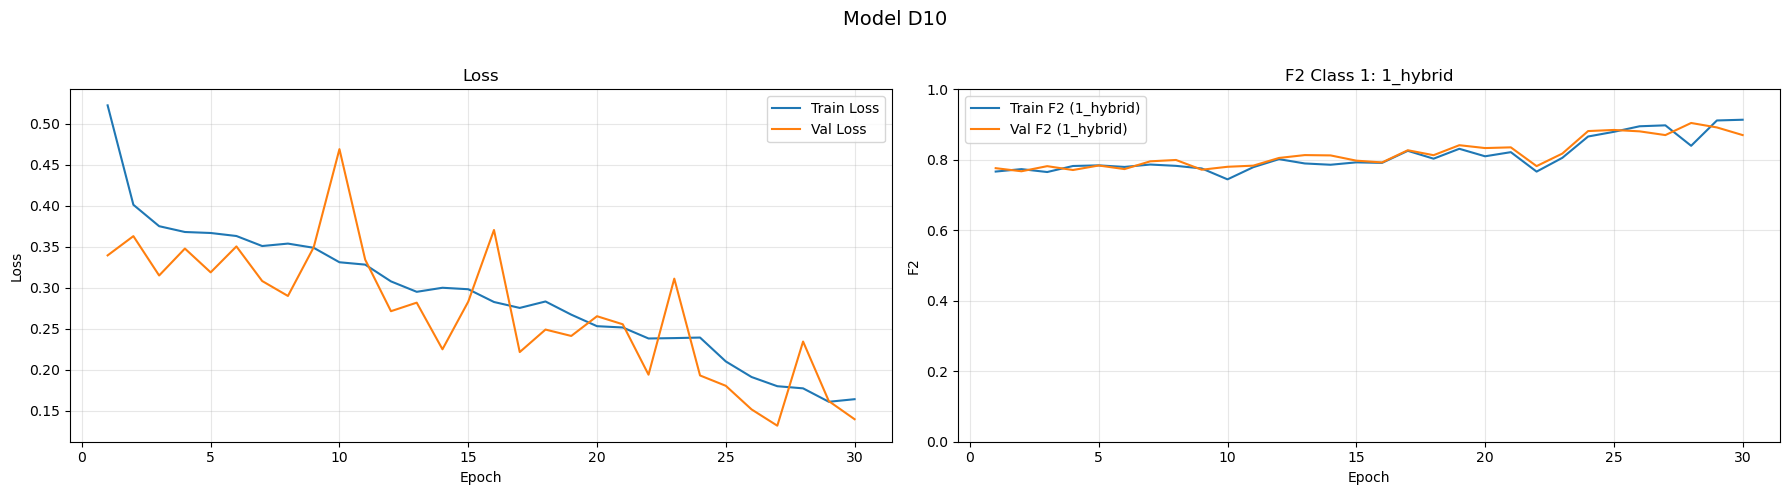

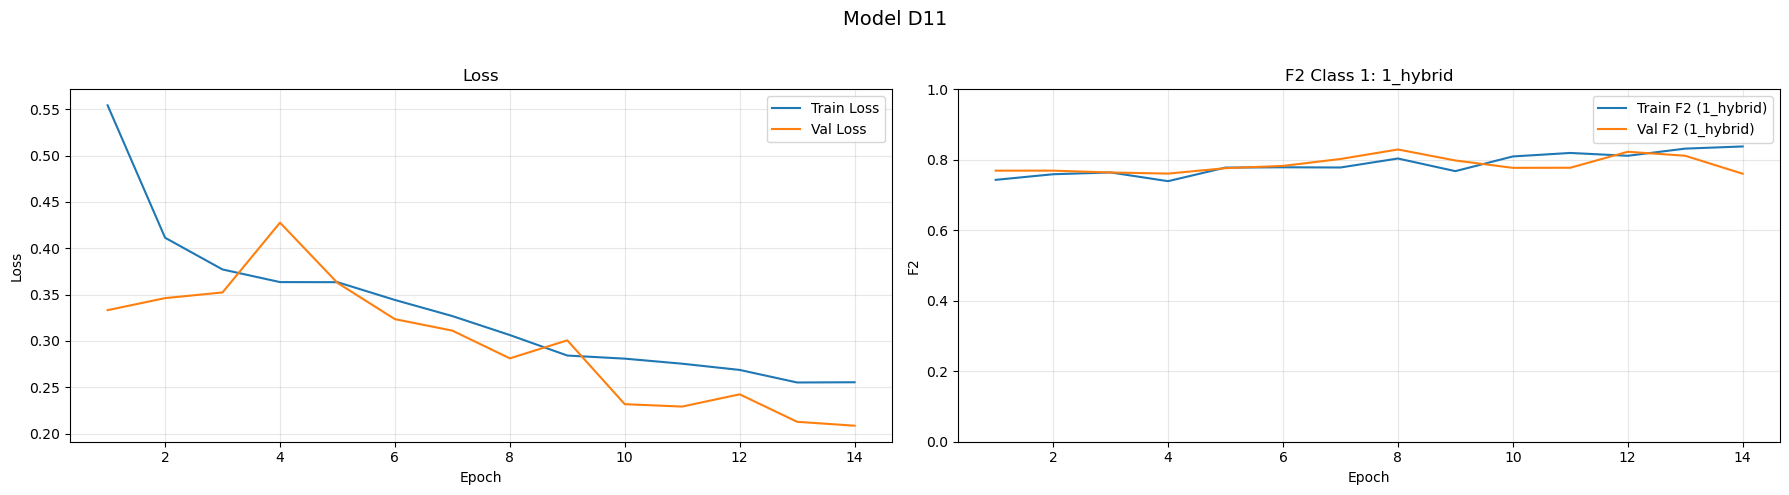

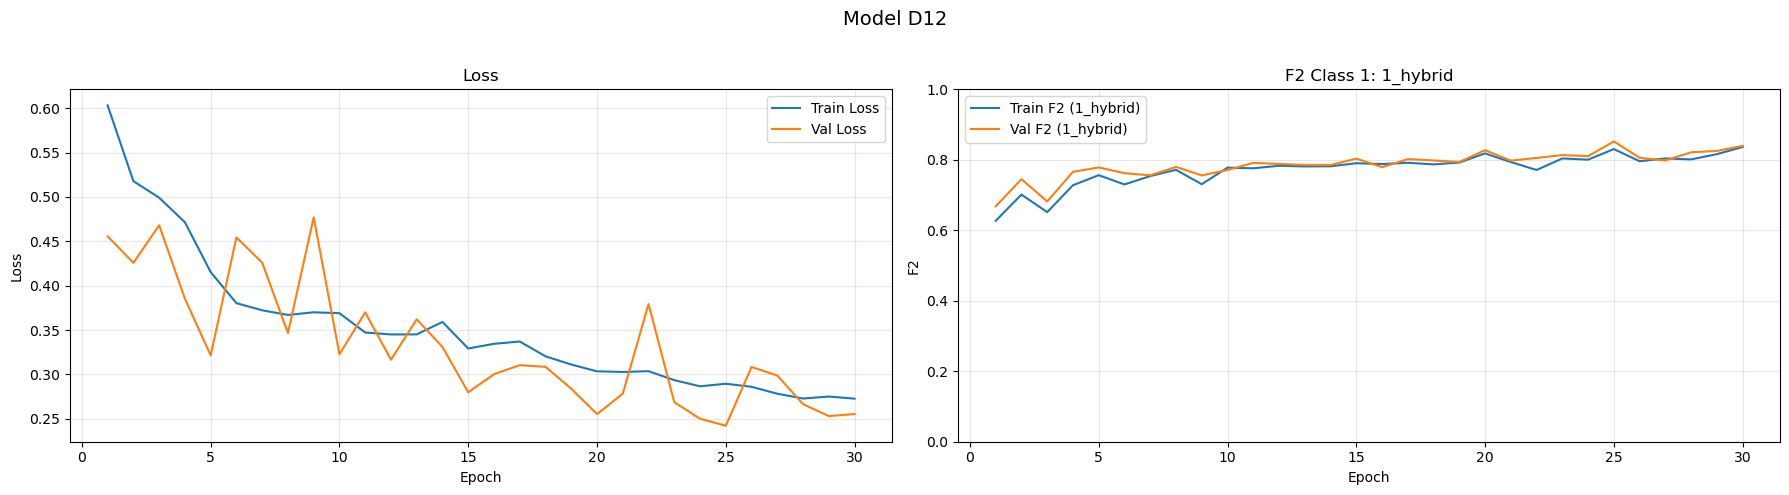

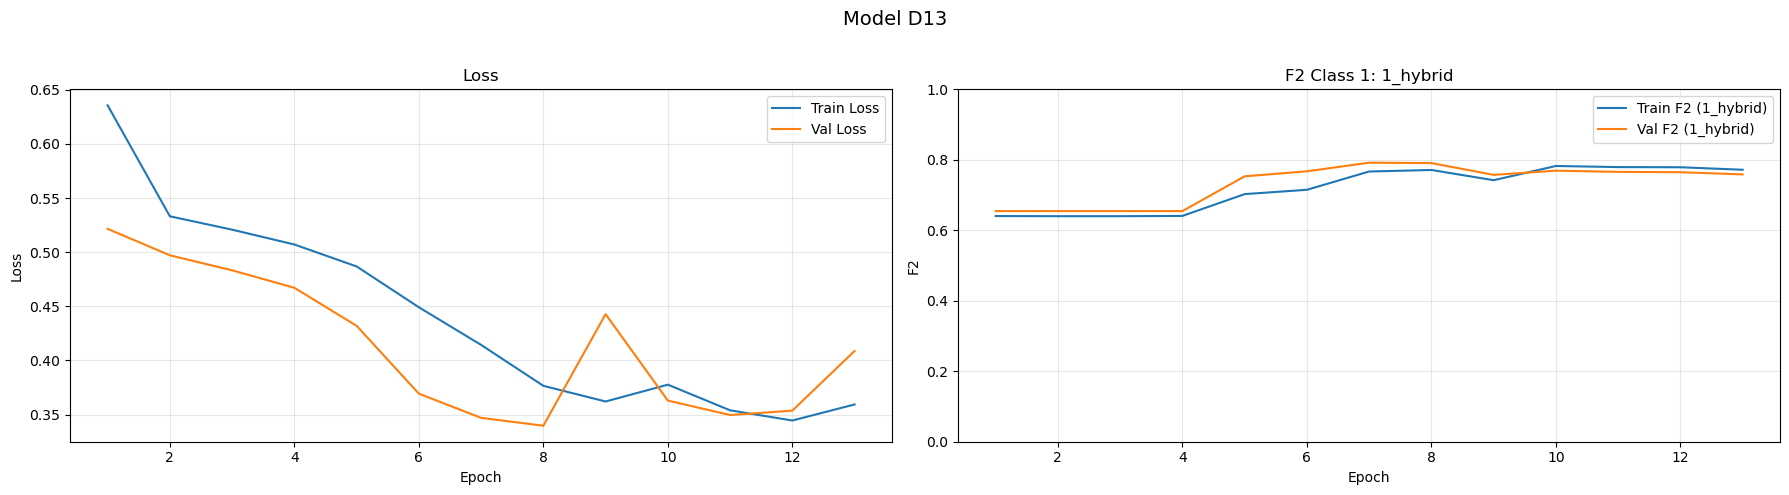

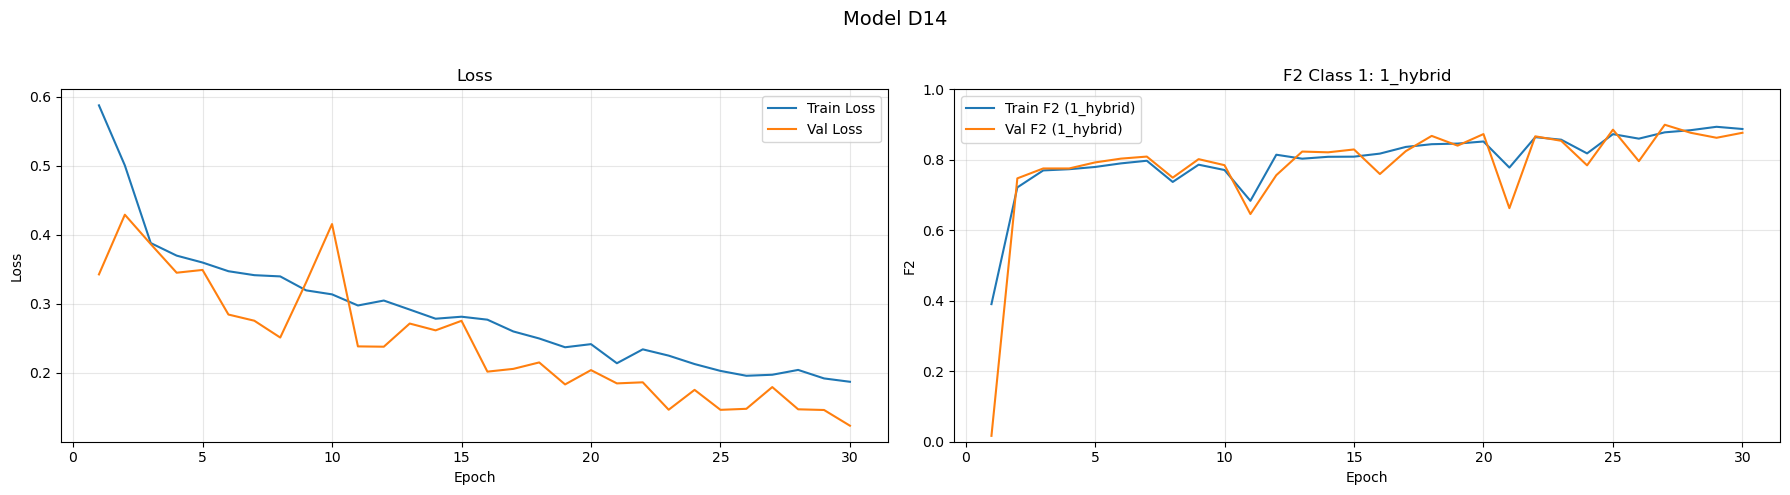

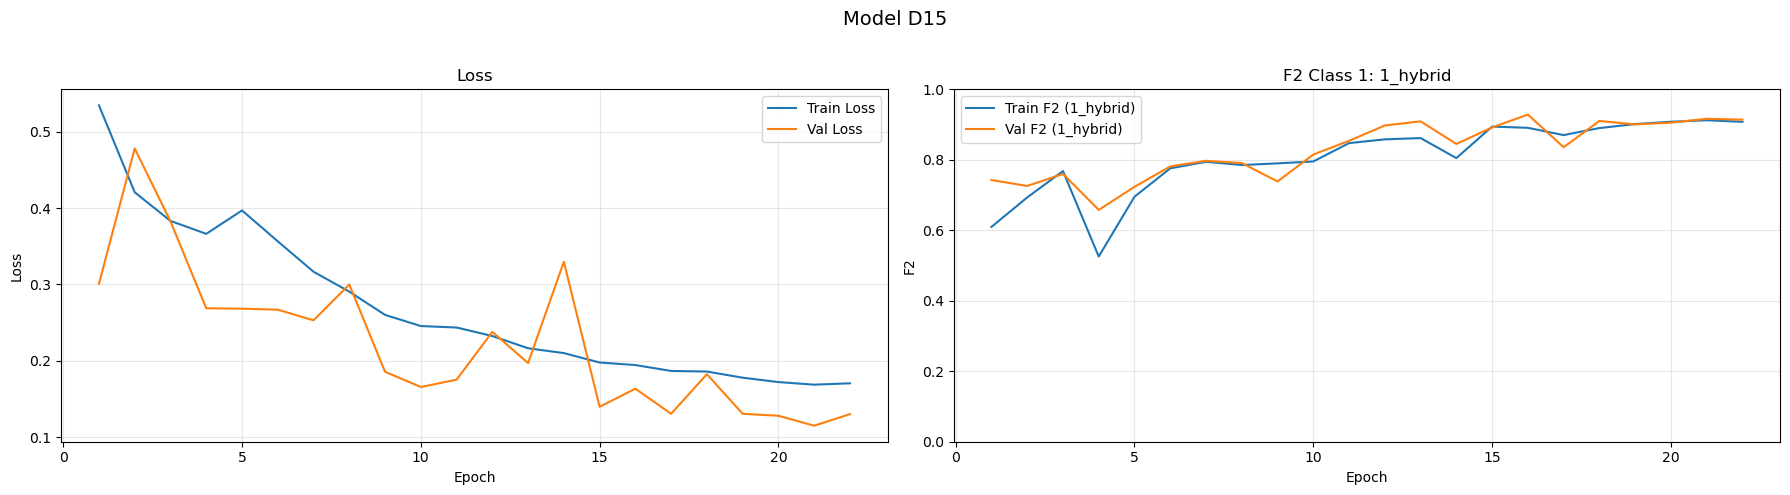

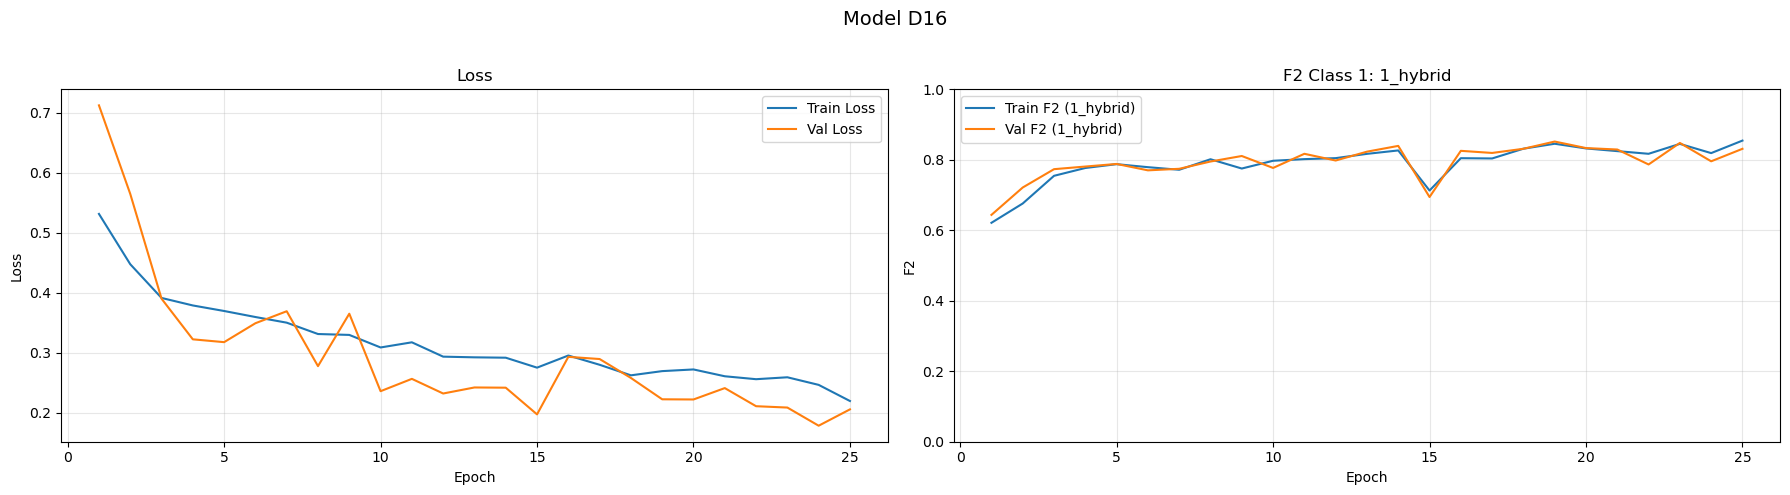

In [13]:
for i in range(1, 17):
    plot_training_curves(model_name=f"Model D{i}", results=results_from_ckpt(model=model_resnet_d_dict[f"model_resnet_d{i}"], ckpt_file=f"../../saved_models/resnet/resnet_d/resnet_model_d{i}_log.pkl"), class_idx=1, class_name="1_hybrid")